In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [6]:
DATA_ROOT = "/kaggle/input/nih-chest-xrays"

In [7]:
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

In [16]:
df = pd.read_csv(f"/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv")

df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [14]:
print(df.shape)

(112120, 12)


In [20]:
df["Target"] = df["Finding Labels"].apply(
    lambda labels: 1 if "Pneumonia" in str(labels).split("|") else 0
)

print(df["Target"].value_counts())

Target
0    110689
1      1431
Name: count, dtype: int64


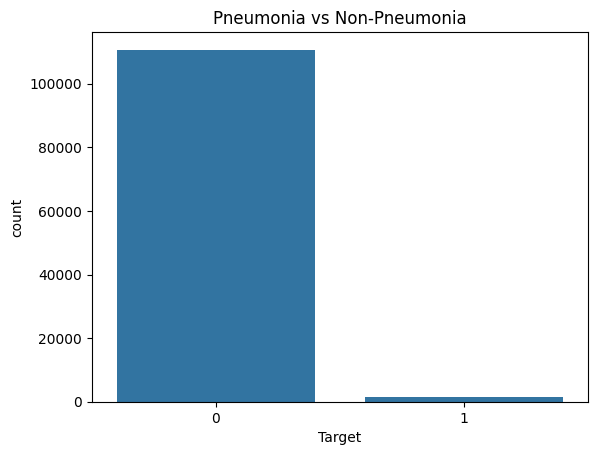

In [21]:
sns.countplot(x="Target", data=df)
plt.title("Pneumonia vs Non-Pneumonia")
plt.show()

In [22]:
pneumonia_df = df[df["Target"] == 1]

non_pneumonia_df = df[df["Target"] == 0].sample(
    n=len(pneumonia_df) * 2,
    random_state=42
)

df_balanced = pd.concat([pneumonia_df, non_pneumonia_df])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced["Target"].value_counts())

Target
0    2862
1    1431
Name: count, dtype: int64


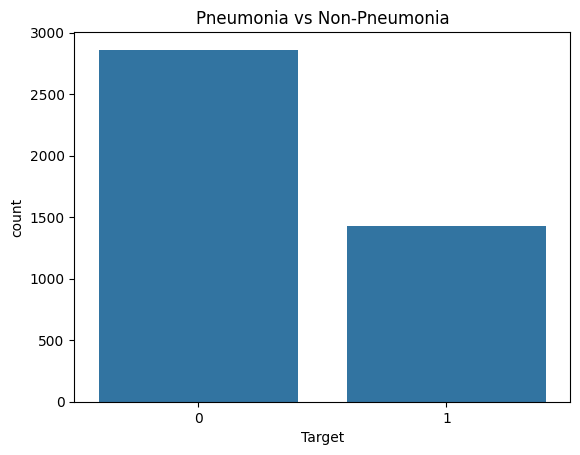

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Target", data=df_balanced)
plt.title("Pneumonia vs Non-Pneumonia")
plt.show()

In [24]:
DATA_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

In [25]:
import os

all_images = []

for root, dirs, files in os.walk(DATA_ROOT):
    for file in files:
        if file.endswith(".png"):
            all_images.append(os.path.join(root, file))

print("Total images found:", len(all_images))
print(all_images[:5])

Total images found: 112120
['/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006199_010.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004833_016.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006260_000.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004911_010.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004186_007.png']


In [27]:
image_path_map = {os.path.basename(x): x for x in all_images}

df_balanced["path"] = df_balanced["Image Index"].map(image_path_map)
df_balanced = df_balanced.dropna(subset=["path"]).reset_index(drop=True)

print(df_balanced.shape)
print(df_balanced["path"].isnull().sum())
df_balanced[["Image Index", "path"]].head()

(4293, 14)
0


,Image Index,path
0,00018472_001.png,/kaggle/input/datasets/organizations/nih-chest...
1,00000116_020.png,/kaggle/input/datasets/organizations/nih-chest...
2,00002003_002.png,/kaggle/input/datasets/organizations/nih-chest...
3,00016490_019.png,/kaggle/input/datasets/organizations/nih-chest...
4,00026050_010.png,/kaggle/input/datasets/organizations/nih-chest...


In [29]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_balanced,
    test_size=0.3,
    stratify=df_balanced["Target"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["Target"],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (3005, 14)
Validation shape: (644, 14)
Test shape: (644, 14)


In [30]:
print("Train target distribution:")
print(train_df["Target"].value_counts())

print("\nValidation target distribution:")
print(val_df["Target"].value_counts())

print("\nTest target distribution:")
print(test_df["Target"].value_counts())

Train target distribution:
Target
0    2003
1    1002
Name: count, dtype: int64

Validation target distribution:
Target
0    429
1    215
Name: count, dtype: int64

Test target distribution:
Target
0    430
1    214
Name: count, dtype: int64


In [58]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [59]:
def clahe_enhancement(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(gray)
    img = cv2.cvtColor(cl, cv2.COLOR_GRAY2RGB)
    return img

In [60]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "path"]
        label = self.dataframe.loc[idx, "Target"]

        image = Image.open(img_path).convert("RGB")
        image = np.array(image)

        image = clahe_enhancement(image)
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [61]:
train_dataset = ChestXrayDataset(train_df, transform=train_transform)
val_dataset = ChestXrayDataset(val_df, transform=val_test_transform)
test_dataset = ChestXrayDataset(test_df, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train dataset size: 3005
Validation dataset size: 644
Test dataset size: 644
Train batches: 94
Validation batches: 21
Test batches: 21


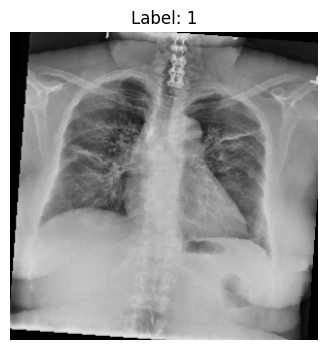

In [62]:
images, labels = next(iter(train_loader))

img = images[0].permute(1, 2, 0).numpy()
img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Label: {int(labels[0].item())}")
plt.axis("off")
plt.show()

In [63]:
import os

os.makedirs("/kaggle/working/processed_data", exist_ok=True)

train_df.to_csv("/kaggle/working/processed_data/train.csv", index=False)
val_df.to_csv("/kaggle/working/processed_data/val.csv", index=False)
test_df.to_csv("/kaggle/working/processed_data/test.csv", index=False)

print("Saved successfully to /kaggle/working/processed_data")

Saved successfully to /kaggle/working/processed_data


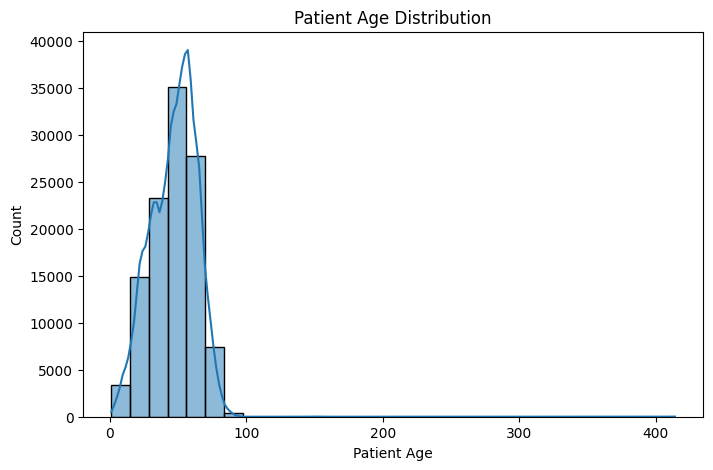

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64


In [64]:
plt.figure(figsize=(8,5))
sns.histplot(df["Patient Age"], bins=30, kde=True)
plt.title("Patient Age Distribution")
plt.show()

print(df["Patient Age"].describe())

Patient Gender
M    63340
F    48780
Name: count, dtype: int64


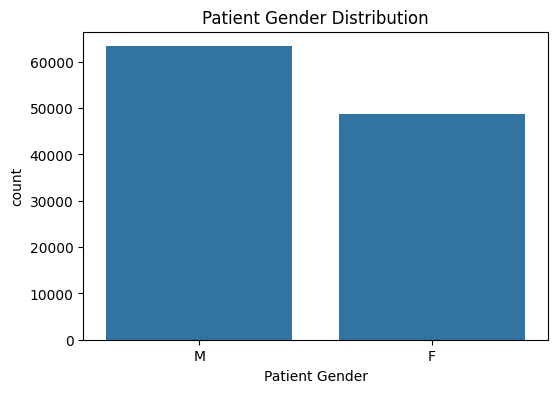

In [65]:
print(df["Patient Gender"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Patient Gender", data=df)
plt.title("Patient Gender Distribution")
plt.show()

View Position
PA    67310
AP    44810
Name: count, dtype: int64


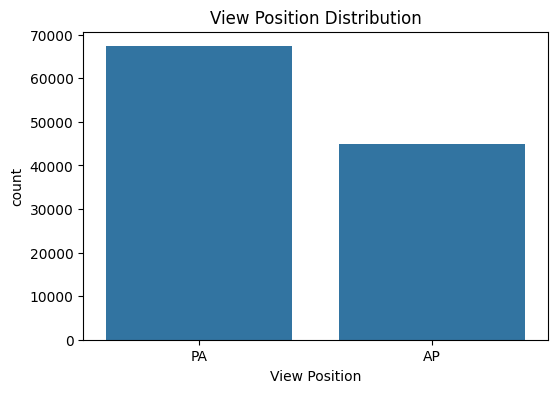

In [66]:
print(df["View Position"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="View Position", data=df)
plt.title("View Position Distribution")
plt.show()

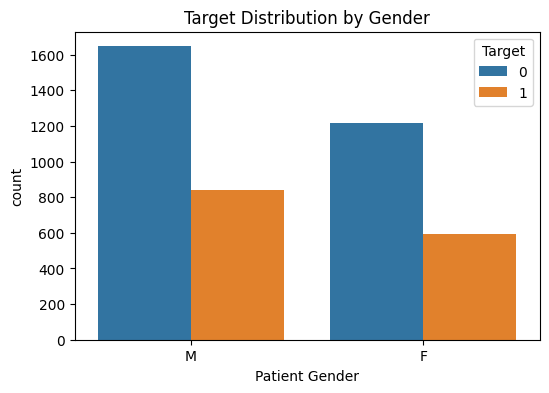

In [67]:
plt.figure(figsize=(6,4))
sns.countplot(x="Patient Gender", hue="Target", data=df_balanced)
plt.title("Target Distribution by Gender")
plt.show()

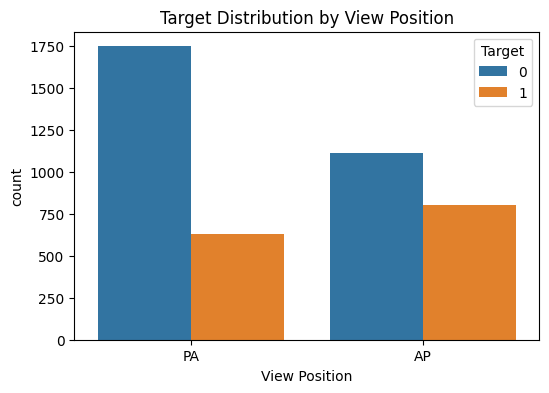

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x="View Position", hue="Target", data=df_balanced)
plt.title("Target Distribution by View Position")
plt.show()

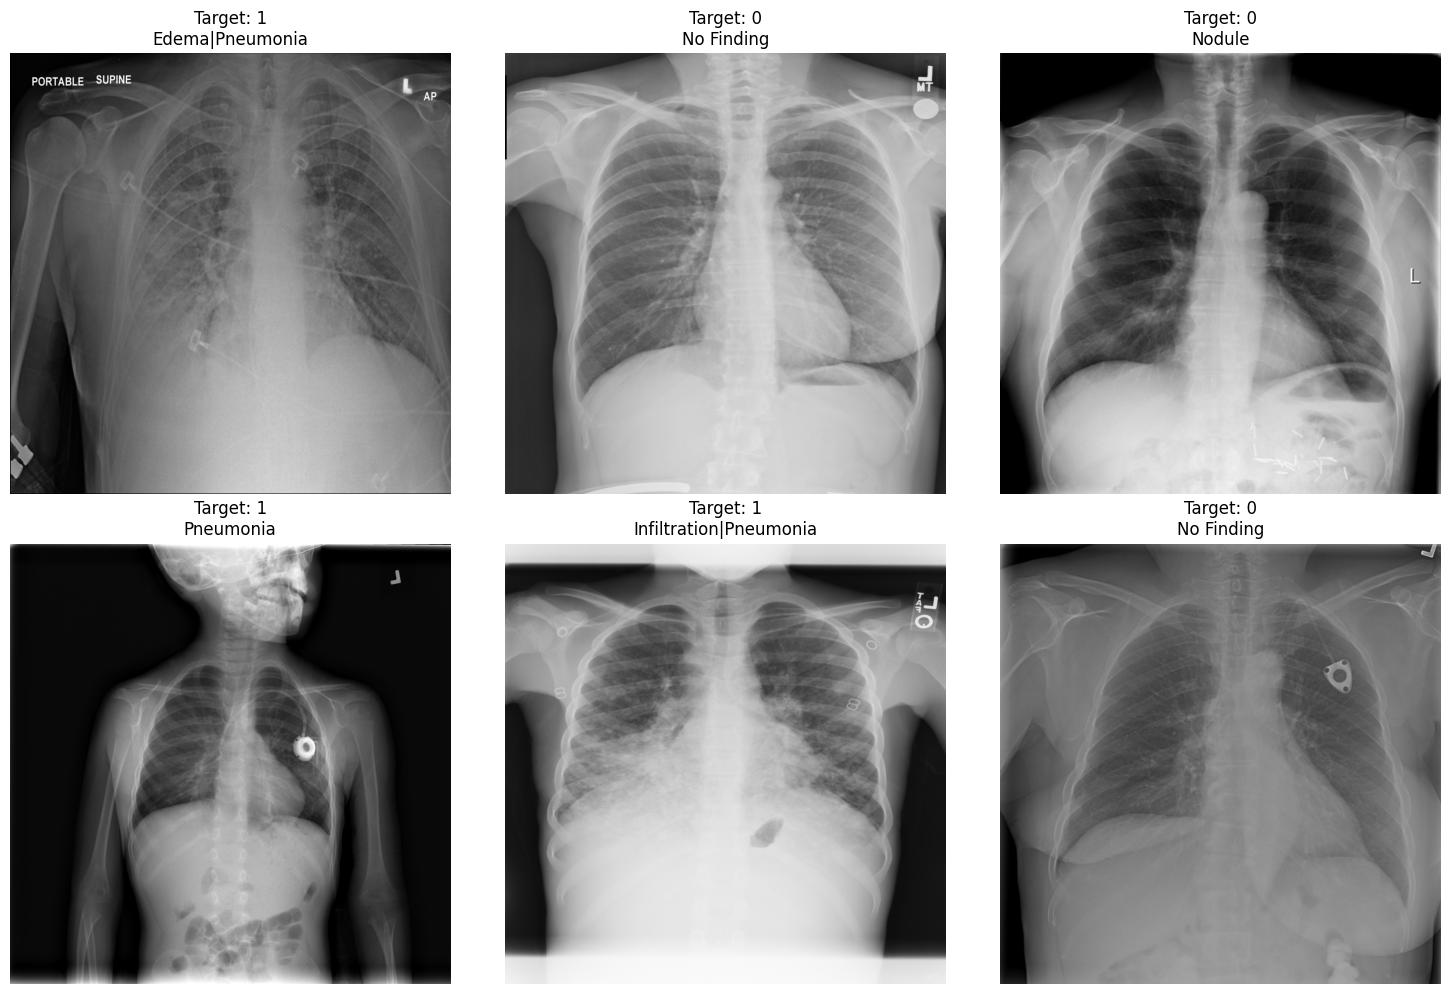

In [69]:
sample_rows = df_balanced.sample(6, random_state=42)

plt.figure(figsize=(15,10))
for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row["path"]).convert("RGB")
    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f'Target: {row["Target"]}\n{row["Finding Labels"]}')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [70]:
print("EDA and preprocessing completed successfully.")
print("Final balanced dataset size:", df_balanced.shape)
print("Train set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

EDA and preprocessing completed successfully.
Final balanced dataset size: (4293, 14)
Train set: (3005, 14)
Validation set: (644, 14)
Test set: (644, 14)


In [99]:
from torchvision import models
from torchvision.models import Inception_V3_Weights
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = models.inception_v3(
    weights=Inception_V3_Weights.DEFAULT,
    aux_logits=True
)

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 1)
)

model.AuxLogits.fc = nn.Linear(
    model.AuxLogits.fc.in_features,
    1
)

cuda


In [100]:
for param in model.parameters():
    param.requires_grad = False

for param in model.Mixed_7c.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

In [101]:
pos_weight = torch.tensor([2.0]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

In [102]:
def train_model(model, train_loader, val_loader, epochs=10):
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()

            outputs, aux_outputs = model(images)

            loss1 = criterion(outputs, labels)
            loss2 = criterion(aux_outputs, labels)

            loss = loss1 + 0.4 * loss2

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)

                outputs = model(images)
                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)
                val_loss += loss.item()

        
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    return history

In [103]:
history = train_model(model, train_loader, val_loader, epochs=8)

Epoch 1 | Train: 122.8428 | Val: 18.8362
Epoch 2 | Train: 118.5485 | Val: 18.5658
Epoch 3 | Train: 117.6801 | Val: 18.4884
Epoch 4 | Train: 114.9686 | Val: 18.7699
Epoch 5 | Train: 113.4617 | Val: 18.8929
Epoch 6 | Train: 112.3666 | Val: 19.1324
Epoch 7 | Train: 110.3299 | Val: 19.0851
Epoch 8 | Train: 108.8527 | Val: 19.0132


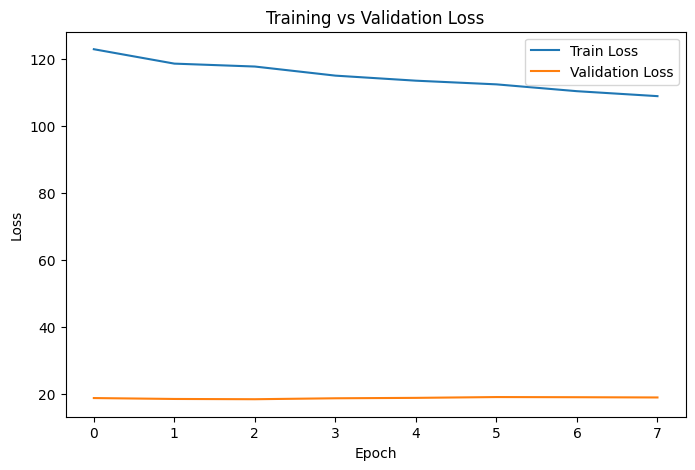

In [104]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [106]:

from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, classification_report, confusion_matrix

import numpy as np

def get_probs(model, loader):

    model.eval()

    probs_all = []
    targets_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            probs = torch.sigmoid(outputs).cpu().numpy().flatten()

            probs_all.extend(probs)
            targets_all.extend(labels.numpy())

    return np.array(targets_all), np.array(probs_all)


targets, probs = get_probs(model, test_loader)

In [107]:
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:

    preds = (probs > th).astype(int)

    print("Threshold:", th)

    print("Accuracy:", accuracy_score(targets, preds))
    print("Precision:", precision_score(targets, preds))
    print("Recall:", recall_score(targets, preds))
    print("F1:", f1_score(targets, preds))

    print("-" * 40)

Threshold: 0.3
Accuracy: 0.4751552795031056
Precision: 0.376
Recall: 0.8785046728971962
F1: 0.5266106442577031
----------------------------------------
Threshold: 0.4
Accuracy: 0.577639751552795
Precision: 0.42487046632124353
Recall: 0.7663551401869159
F1: 0.5466666666666666
----------------------------------------
Threshold: 0.5
Accuracy: 0.6350931677018633
Precision: 0.4628975265017668
Recall: 0.6121495327102804
F1: 0.5271629778672032
----------------------------------------
Threshold: 0.6
Accuracy: 0.6692546583850931
Precision: 0.5025906735751295
Recall: 0.4532710280373832
F1: 0.47665847665847666
----------------------------------------
Threshold: 0.7
Accuracy: 0.6739130434782609
Precision: 0.5178571428571429
Recall: 0.27102803738317754
F1: 0.3558282208588957
----------------------------------------


In [108]:

best_acc = 0
best_th = 0

for th in np.arange(0.3, 0.9, 0.05):

    preds = (probs > th).astype(int)

    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds)

    print(f"Threshold: {th:.2f} | Acc: {acc:.4f} | F1: {f1:.4f}")

    if acc > best_acc:

        best_acc = acc
        best_th = th

print("Best threshold:", best_th)
print("Best accuracy:", best_acc)

Threshold: 0.30 | Acc: 0.4752 | F1: 0.5266
Threshold: 0.35 | Acc: 0.5248 | F1: 0.5392
Threshold: 0.40 | Acc: 0.5776 | F1: 0.5467
Threshold: 0.45 | Acc: 0.6196 | F1: 0.5521
Threshold: 0.50 | Acc: 0.6351 | F1: 0.5272
Threshold: 0.55 | Acc: 0.6522 | F1: 0.4955
Threshold: 0.60 | Acc: 0.6693 | F1: 0.4767
Threshold: 0.65 | Acc: 0.6630 | F1: 0.4119
Threshold: 0.70 | Acc: 0.6739 | F1: 0.3558
Threshold: 0.75 | Acc: 0.6770 | F1: 0.2925
Threshold: 0.80 | Acc: 0.6708 | F1: 0.1908
Threshold: 0.85 | Acc: 0.6755 | F1: 0.1255
Threshold: 0.90 | Acc: 0.6677 | F1: 0.0273
Best threshold: 0.7499999999999999
Best accuracy: 0.6770186335403726


In [109]:

preds = (probs > best_th).astype(int)

print(
    classification_report(
        targets,
        preds,
        target_names=["Non-Pneumonia", "Pneumonia"]
    )
)

               precision    recall  f1-score   support

Non-Pneumonia       0.70      0.91      0.79       430
    Pneumonia       0.54      0.20      0.29       214

     accuracy                           0.68       644
    macro avg       0.62      0.56      0.54       644
 weighted avg       0.64      0.68      0.63       644



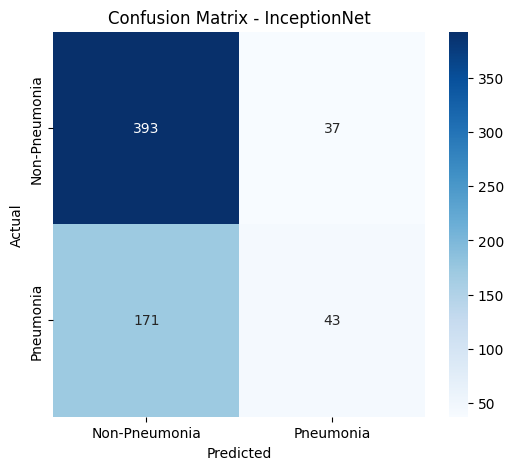

In [110]:
cm = confusion_matrix(targets, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Pneumonia", "Pneumonia"],
    yticklabels=["Non-Pneumonia", "Pneumonia"]
)

plt.title("Confusion Matrix - InceptionNet")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [111]:
torch.save(model.state_dict(), "inceptionnet_model.pth")

print("Model Saved Successfully")

Model Saved Successfully


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


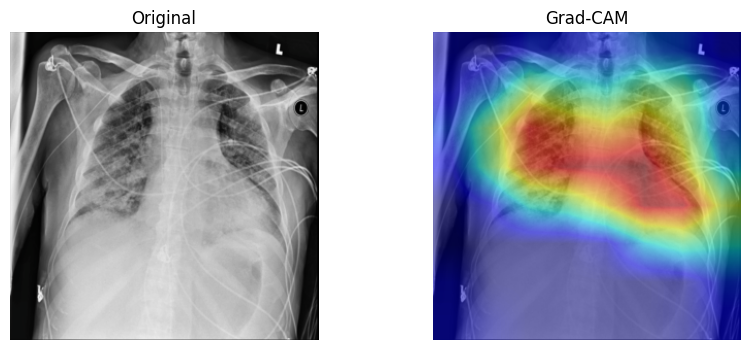

In [112]:
import cv2

def generate_gradcam(model, image, target_layer):

    model.eval()

    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(image)

    if isinstance(output, tuple):
        output = output[0]

    model.zero_grad()

    output.backward()

    grad = gradients[0].cpu().data.numpy()[0]
    act = activations[0].cpu().data.numpy()[0]

    weights = np.mean(grad, axis=(1,2))

    cam = np.zeros(act.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * act[i]

    cam = np.maximum(cam, 0)

    cam = cv2.resize(cam, (299,299))

    cam = cam - np.min(cam)

    if np.max(cam) != 0:
        cam = cam / np.max(cam)

    f_handle.remove()
    b_handle.remove()

    return cam


images, labels = next(iter(test_loader))

img = images[0].unsqueeze(0).to(device)

cam = generate_gradcam(
    model,
    img,
    model.Mixed_7c
)

img_np = images[0].permute(1,2,0).numpy()

img_np = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])

img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

In [113]:

!pip install lime -q

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.6051416].


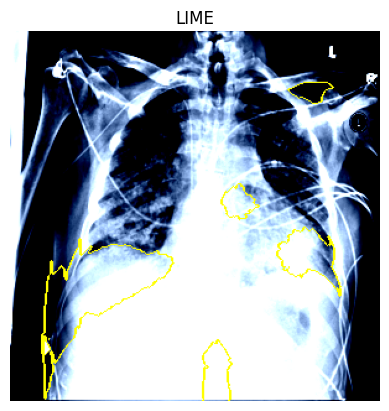

In [114]:

from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

def predict_fn(images):

    images = torch.tensor(images).permute(0,3,1,2).float().to(device)

    outputs = model(images)

    if isinstance(outputs, tuple):
        outputs = outputs[0]

    probs = torch.sigmoid(outputs).detach().cpu().numpy()

    return np.concatenate([1-probs, probs], axis=1)


image = images[0].permute(1,2,0).numpy()

explanation = explainer.explain_instance(
    image,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME")
plt.axis("off")

plt.show()

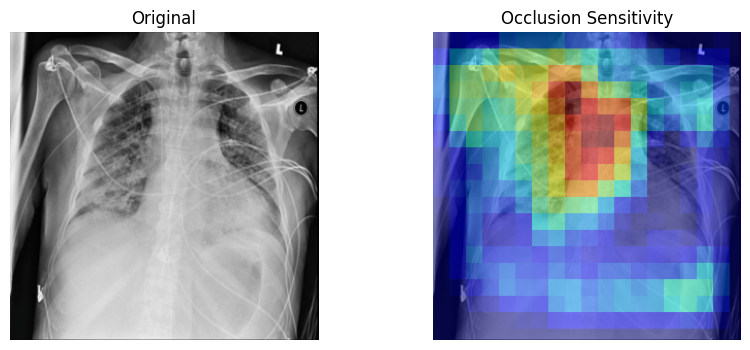

In [115]:

def occlusion_sensitivity(
    model,
    image,
    patch_size=32,
    stride=16
):

    model.eval()

    image = image.clone().detach().to(device)

    with torch.no_grad():

        output = model(image)

        if isinstance(output, tuple):
            output = output[0]

        original_score = torch.sigmoid(output)[0,0].item()

    _, _, h, w = image.shape

    heatmap = np.zeros((h,w), dtype=np.float32)

    for y in range(0, h-patch_size+1, stride):

        for x in range(0, w-patch_size+1, stride):

            occluded = image.clone()

            occluded[:,:,y:y+patch_size, x:x+patch_size] = 0

            with torch.no_grad():

                output = model(occluded)

                if isinstance(output, tuple):
                    output = output[0]

                score = torch.sigmoid(output)[0,0].item()

            heatmap[y:y+patch_size, x:x+patch_size] += (
                original_score - score
            )

    heatmap = np.maximum(heatmap, 0)

    heatmap = heatmap - heatmap.min()

    if heatmap.max() != 0:
        heatmap = heatmap / heatmap.max()

    return heatmap


occ_map = occlusion_sensitivity(model, img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(occ_map, cmap="jet", alpha=0.5)
plt.title("Occlusion Sensitivity")
plt.axis("off")

plt.show()

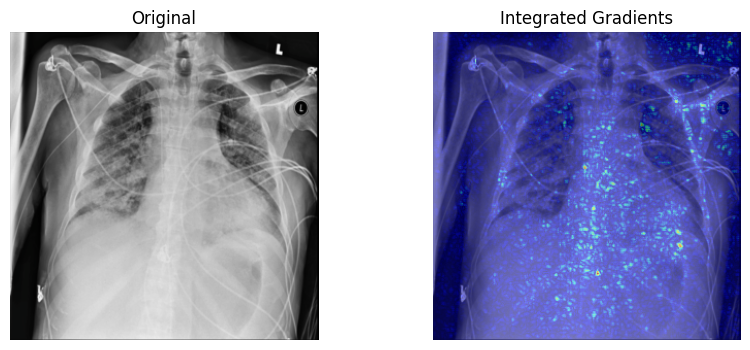

In [116]:

def integrated_gradients(
    model,
    image,
    baseline=None,
    steps=30
):

    model.eval()

    image = image.clone().detach().to(device)

    if baseline is None:
        baseline = torch.zeros_like(image).to(device)

    total_gradients = torch.zeros_like(image)

    for i in range(1, steps+1):

        alpha = i / steps

        scaled_img = baseline + alpha * (image - baseline)

        scaled_img.requires_grad_(True)

        output = model(scaled_img)

        if isinstance(output, tuple):
            output = output[0]

        score = output[0,0]

        model.zero_grad()

        score.backward()

        total_gradients += scaled_img.grad.detach()

    avg_gradients = total_gradients / steps

    integrated = (image - baseline) * avg_gradients

    ig_map = integrated.squeeze().detach().cpu().numpy()

    ig_map = np.max(np.abs(ig_map), axis=0)

    ig_map = (
        ig_map - ig_map.min()
    ) / (
        ig_map.max() - ig_map.min() + 1e-8
    )

    return ig_map


ig_map = integrated_gradients(model, img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(ig_map, cmap="jet", alpha=0.5)
plt.title("Integrated Gradients")
plt.axis("off")

plt.show()